# Dipole Antenna Mesh with PalaceToolkit

This notebook uses PalaceToolkit utilities with a robust workflow:
- build primitives
- fragment once for conformal topology
- define `Entity` objects from fragmented geometry
- run `run_meshing_pipeline`, refine with `refine_near_surfaces`, then `generate_3d_mesh`
- visualize with `palacetoolkit.viz`


In [38]:
from pathlib import Path
import math
import gmsh

from palacetoolkit.geometry import xmin, xmax, ymin, ymax, zmin, zmax, extract_tag
from palacetoolkit.mesh import Entity, run_meshing_pipeline, generate_3d_mesh, refine_near_surfaces
from palacetoolkit.viz import view_mesh
from palacetoolkit.simulation import generate_palace_config_from_entities, run_palace
from palacetoolkit.verify_topology import verify, print_report, visualise_problems

In [ ]:
wavelength = 4.0
arm_length = wavelength / 4
arm_radius = arm_length / 20
gap_size = arm_length / 50
outer_boundary_radius = 1.5 * wavelength
mesh_file = "dipole.msh"

In [40]:
if gmsh.isInitialized():
    gmsh.finalize()
gmsh.initialize()
gmsh.option.setNumber("General.Verbosity", 2)
gmsh.model.add("dipole_entity_pipeline")
occ = gmsh.model.occ

air = occ.addSphere(0, 0, 0, outer_boundary_radius)
top_arm = occ.addBox(-arm_radius, -arm_radius, gap_size / 2, 2 * arm_radius, 2 * arm_radius, arm_length)
bot_arm = occ.addBox(-arm_radius, -arm_radius, -gap_size / 2 - arm_length, 2 * arm_radius, 2 * arm_radius, arm_length)
port_sheet = occ.addRectangle(-arm_radius, -gap_size / 2, 0, 2 * arm_radius, gap_size)
occ.rotate([(2, port_sheet)], 0, 0, 0, 1, 0, 0, math.pi / 2)
occ.synchronize()

In [41]:
# Entity + boolean pipeline for named physical groups.
entities = [
    Entity("air", dim=3, mesh_order=2, btype="dielectric", tags=[air], loss_tan=0.0, eps_r=1.0, mu_r=1.0),
    Entity("top_arm", dim=3, mesh_order=1, btype="pec", tags=[top_arm]),
    Entity("bot_arm", dim=3, mesh_order=1, btype="pec", tags=[bot_arm]),
    Entity("port", dim=2, mesh_order=0, btype="lumped_port", tags=[port_sheet], R=50.0, direction="+Z", excitation=True),
]
pg_map = run_meshing_pipeline(entities)

refine_near_surfaces(
    entities[2].dimtags,
    wavelength,
    ppw_near=30,
    ppw_far=5,
    transition_distance=wavelength / 4,
    set_as_background=True
)

generate_3d_mesh(entities, output_file=mesh_file, optimize=True)
gmsh.finalize()
pg_map

  Physical group 'air' (dim=3): pg=1, tags=[1]
  Physical group 'top_arm' (dim=3): pg=2, tags=[2]
  Physical group 'bot_arm' (dim=3): pg=3, tags=[3]
  Physical group 'port' (dim=2): pg=4, tags=[14]
  Physical group 'air__None' (dim=2): pg=5, tags=[23]
  Physical group 'air__bot_arm' (dim=2): pg=6, tags=[19, 10, 21, 22, 11, 12, 20]
  Physical group 'air__top_arm' (dim=2): pg=7, tags=[15, 4, 7, 5, 17, 18, 16]
  ppw_near=30  ppw_far=5
  SizeMax=0.8000  transition=1.0000
  global: 7 curves, SizeMin=0.1333


Mesh saved to dipole.msh
  Nodes: 1985
  Elements: 10847


{'port': 4,
 'air__None': 5,
 'air__bot_arm': 6,
 'air__top_arm': 7,
 'air': 1,
 'top_arm': 2,
 'bot_arm': 3}

In [42]:
view_mesh(mesh_file, transparent_groups=["air__None"])

Loading mesh file: dipole.msh
Groups to render transparent: ['air__None']

Mesh loaded successfully with 2 cell blocks
Found 2006 triangles total
Physical group tags in mesh: {4: 'port', 5: 'air__None', 6: 'air__bot_arm', 7: 'air__top_arm'}


In [43]:
config_file: str = "dipole_antenna.json"
mesh_file = "dipole.msh"

# Frequency sweep centered around the dipole resonance.
# Each arm is lambda/4, so total dipole length is lambda/2 and
# the resonant frequency is approximately f0 = c / lambda.
c0 = 299_792_458.0
f0_hz = c0 / wavelength
f0_ghz = f0_hz / 1e9

freq_min: float = 0.75 * f0_ghz
freq_max: float = 1.25 * f0_ghz
freq_step: float = (freq_max-freq_min)/20
solver_order: int = 2

print(f"Estimated f0 = {f0_ghz:.6f} GHz")
print(f"Sweep: {freq_min:.6f} to {freq_max:.6f} GHz (step {freq_step:.6f} GHz)")

generate_palace_config_from_entities(entity_defs = [e.to_dict() for e in entities],
    pg_map = pg_map,
    mesh_file = mesh_file,
    output_file = config_file,
    freq_min = freq_min,
    freq_max = freq_max,
    freq_step = freq_step ,
    L0 = 1.0,
    solver_order = solver_order,
    absorbing_order = 2,
    farfield=True)

Estimated f0 = 0.074948 GHz
Sweep: 0.056211 to 0.093685 GHz (step 0.001874 GHz)
Palace config written to dipole_antenna.json


{'Problem': {'Type': 'Driven',
  'Verbose': 2,
  'Output': 'postpro/dipole_antenna'},
 'Model': {'Mesh': 'dipole.msh', 'L0': 1.0, 'Refinement': {}},
 'Domains': {'Materials': [{'Attributes': [1],
    'Permeability': 1.0,
    'Permittivity': 1.0,
    'LossTan': 0.0}]},
 'Boundaries': {'PEC': {'Attributes': [2, 3]},
  'Absorbing': {'Attributes': [5, 6, 7], 'Order': 2},
  'LumpedPort': [{'Index': 1,
    'Attributes': [4],
    'R': 50.0,
    'Excitation': True,
    'Direction': '+Z'}],
  'Postprocessing': {'FarField': {'Attributes': [5, 6, 7], 'NSample': 16000}}},
 'Solver': {'Order': 2,
  'Device': 'CPU',
  'Driven': {'MinFreq': 0.056211085875,
   'MaxFreq': 0.093685143125,
   'FreqStep': 0.0018737028625,
   'SaveStep': 5,
   'AdaptiveTol': 0.001},
  'Linear': {'Type': 'Default',
   'KSPType': 'GMRES',
   'Tol': 1e-08,
   'MaxIts': 500}}}

In [44]:
# Validate topology before launching Palace.
topology_result = verify(mesh_file, config_file)
topology_ok = print_report(topology_result)

if not topology_ok:
    print("Topology validation failed; opening mesh viewer in debug mode (problem faces highlighted).")
    visualise_problems(
        mesh_file,
        topology_result,
        transparent_groups=["air__None"],
        exclude_expected_periodic=False,
        only_nonmanifold=False,
    )
    raise RuntimeError("Mesh topology validation failed. Fix mesh/topology issues before running Palace.")



╔══════════════════════════════════════════════════════════════════════╗
║              Mesh Topological Consistency Report                    ║
╚══════════════════════════════════════════════════════════════════════╝

  Mesh file:             dipole.msh
  Vertices:              1,985
  Tetrahedra:            8,719
  Boundary triangles:    2,006
  Unique volume faces:   18,375
    interior (2 tets):   16,501
    skin     (1 tet):    1,874

  Physical groups (2-D):
    attr   1 = air
    attr   2 = top_arm
    attr   3 = bot_arm
    attr   4 = port
    attr   5 = air__None
    attr   6 = air__bot_arm
    attr   7 = air__top_arm

──────────────────────────────────────────────────────────────────────
  CHECK 1  —  Totality:  every boundary face ∈ volume faces
              (violation → MFEM abort: (r,c,f) = …)
──────────────────────────────────────────────────────────────────────
  ❌  Pass 1 (raw): 2 ORPHAN boundary face(s)!

    By boundary attribute:
      attr 4 (port): 2 orphan(s)



RuntimeError: Mesh topology validation failed. Fix mesh/topology issues before running Palace.

In [ ]:
run_palace(config_file=config_file, num_procs=16)

  Running: /home/martin/.cache/palacetoolkit/runtime/palace-cpu-v0.1.2/bin/palace -np 16 /home/martin/Desktop/PalaceToolkit/docs/examples/dipole_antenna.json
>> /usr/bin/mpirun -n 16 /home/martin/.cache/palacetoolkit/runtime/palace-cpu-v0.1.2/bin/palace-x86_64.bin /home/martin/Desktop/PalaceToolkit/docs/examples/dipole_antenna.json

_____________     _______
_____   __   \____ __   /____ ____________
____   /_/  /  __ ` /  /  __ ` /  ___/  _ \
___   _____/  /_/  /  /  /_/  /  /__/  ___/
  /__/     \___,__/__/\___,__/\_____\_____/


--> Warning!
Output folder is not empty; program will overwrite content! (postpro/dipole_antenna)
Git changeset ID: v0.16.1-51-g4f2e2d97
Running with 16 MPI processes, 1 OpenMP thread
Device configuration: omp,cpu
Memory configuration: host-std
libCEED backend: /cpu/self/xsmm/blocked

Removed 204 unmarked domain elements from the mesh

Characteristic length and time scales:
 Lc = 1.200e+01 m, tc = 4.003e+01 ns
Finished partitioning mesh into 16 subdomains

M

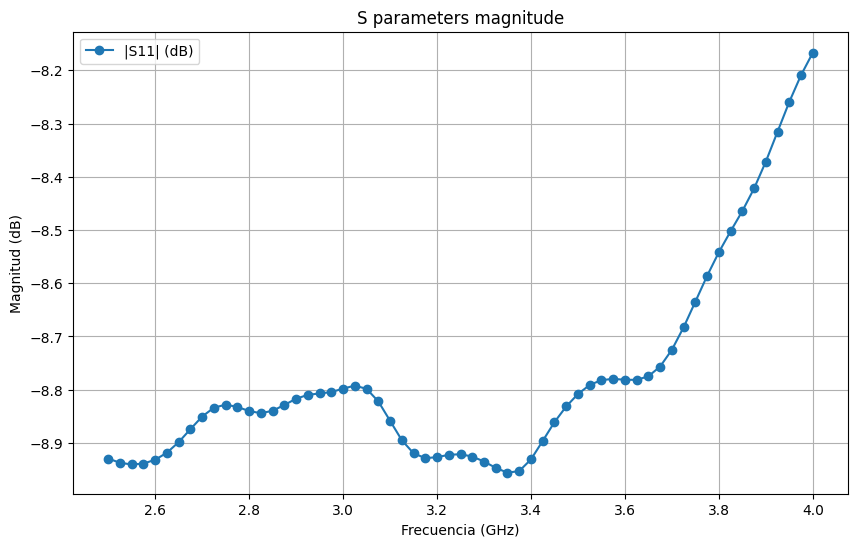

In [ ]:
# S parameters. Return the frequency where the minimum is reached.
from pathlib import Path
from palacetoolkit.postpro import s_params

notebook_dir = Path().resolve()
postpro_dir = notebook_dir / "postpro" / "dipole_antenna"
    
f = s_params(str(postpro_dir / "port-S.csv"))